# Minimal GC-Mamba Internals Notebook

This notebook compares the frozen-from-vanilla GC-Mamba `di64_ds32` and `di128_ds64` checkpoints. It keeps access to the learned Mamba kernels, then runs a tiny warm rollout and traces the internal SSM decomposition:

`SSM_out_h = sum_n h_t[d, n] * C_t[n]`, `SSM_out_u = D[d] * u_t[d]`, their gated forms `y_h` / `y_u`, and their projected outputs through `out_proj`.

Run from the repo root inside `scripts/graphcast_env.sh`.

In [ ]:
from __future__ import annotations

import contextlib
import json
import math
import os
import re
import sys
from pathlib import Path

import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import xarray as xr


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / "scripts/graphcast_env.sh").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find Weather_global repo root.")


ROOT = find_repo_root()
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".tmp/matplotlib"))
(ROOT / ".tmp/matplotlib").mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.graphcast.runtime import _constant_inputs, _dataset_to_numpy, _update_inputs
from src.models.graphcast.training.core.batching import input_steps_from_duration
from src.models.graphcast.training.core.model import casting, gc, load_graphcast_checkpoint, load_stats, normalization, validate_stats_coverage
from src.models.graphcast.training.core.prepared_data import open_prepared_store
from src.models.mamba.gc_mamba.runtime import _apply_temporal_config, _temporal_kwargs
from src.models.mamba.modules.temporal_mesh_mamba_Ilya import (
    _DepthwiseCausalConv1D,
    _cfg_value,
    _resolve_d_inner,
    _resolve_dt_rank,
    TemporalLayerState,
    init_temporal_state,
    reset_temporal_state,
)

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 120

INSERTION_RE = re.compile(r"mesh_interleaved_temporal_r(?P<rep>\d+)_s(?P<step>\d+)")
MAMBA_BLOCK_RE = re.compile(r"mamba_block_(?P<layer>\d+)")
BASE_DIR = ROOT / "artifacts/checkpoints/7_years/mamba_frozen_from_vanilla_mp6_20k_res2_target_steps_bptt16"
CHECKPOINT_FILE = "ckpt_best.npz"
RUNS = {
    "di16_ds16": BASE_DIR / "vanilla_gc_7y_res2_m4_w512_mp6_h6_bs8_accum1_stream50k_gc_mamba_tc2_di16_ds16_20k_target_step12_bptt16",
    "di64_ds16": BASE_DIR / "vanilla_gc_7y_res2_m4_w512_mp6_h6_bs8_accum1_stream50k_gc_mamba_tc2_di64_ds16_20k_target_step12_bptt16",
}
CKPT_PATHS = {label: run_dir / CHECKPOINT_FILE for label, run_dir in RUNS.items()}
DEFAULT_STATS_DIR = ROOT / "data/graphcast/graphcast/stats"
DEFAULT_PREPARED_ROOT = ROOT / "data/graphcast/graphcast/dataset/prepared_stream"
ROLLOUT_STEPS = 24
TRACE_FINAL_INPUT_INDEX: int | None = None
RNG = jax.random.PRNGKey(0)


def load_run_config(run_dir: Path) -> dict:
    with (run_dir / "run_config.json").open("r", encoding="utf-8") as f:
        return json.load(f)


def insertion_name(path: str) -> str:
    match = INSERTION_RE.search(path)
    if match is None:
        return "unknown"
    return f"r{match.group('rep')}_s{match.group('step')}"


def short_tensor_name(path: str) -> str:
    marker = "~_run_sequence/"
    return path.split(marker, 1)[1] if marker in path else path


def l2_norm(arr: np.ndarray) -> float:
    values = np.asarray(arr, dtype=np.float64)
    return float(np.linalg.norm(values.reshape(-1)))


def rms(arr: np.ndarray) -> float:
    values = np.asarray(arr, dtype=np.float64)
    return float(np.sqrt(np.mean(values * values))) if values.size else float("nan")


## Flow Reminder

For one temporal insertion, GraphCast provides mesh latent `x` with feature width `d_model`.

1. `LayerNorm(x)`
2. `in_proj: d_model -> 2 * d_inner`, split into `x_branch` and `res_branch`
3. `x_branch -> depthwise conv1d -> silu = u`
4. `x_proj(u)` generates `delta_raw`, `B_t`, `C_t`; `dt_proj(delta_raw)` gives `delta_t`
5. `A = -exp(A_log)`, `D` is the skip vector
6. `h_t = exp(delta_t * A) * h_{t-1} + delta_t * B_t * u_t`
7. `SSM_out_h = C_t h_t`, `SSM_out_u = D u_t`
8. gate both pieces with `silu(res_branch)`, then project back with `out_proj: d_inner -> d_model`
9. the temporal block returns `x + out_proj(y_h + y_u)`


In [3]:
RUN_CONFIGS = {label: load_run_config(run_dir) for label, run_dir in RUNS.items()}
CHECKPOINTS = {label: load_graphcast_checkpoint(path) for label, path in CKPT_PATHS.items()}
STATS = {}

for label, ckpt in CHECKPOINTS.items():
    run_cfg = RUN_CONFIGS[label]
    temporal_cfg = run_cfg["temporal_config"]
    assert temporal_cfg["bias"] is False, "out_proj decomposition assumes temporal_config.bias=False"
    stats_dir = ROOT / run_cfg.get("stats_dir", str(DEFAULT_STATS_DIR))
    STATS[label] = load_stats(stats_dir)
    validate_stats_coverage(ckpt.task_config, STATS[label])
    print(label)
    print("  checkpoint:", CKPT_PATHS[label])
    print("  model_config:", ckpt.model_config)
    print("  temporal_config:", {k: temporal_cfg[k] for k in ["d_inner", "d_state", "d_conv", "dt_rank", "layers", "insert_count", "stateful", "bias"]})


di16_ds16
  checkpoint: /scratch/gpfs/DABANIN/iv9432/Weather_global/artifacts/checkpoints/7_years/mamba_frozen_from_vanilla_mp6_20k_res2_target_steps_bptt16/vanilla_gc_7y_res2_m4_w512_mp6_h6_bs8_accum1_stream50k_gc_mamba_tc2_di16_ds16_20k_target_step12_bptt16/ckpt_best.npz
  model_config: ModelConfig(resolution=2.0, mesh_size=4, latent_size=512, gnn_msg_steps=6, hidden_layers=1, radius_query_fraction_edge_length=0.6, mesh2grid_edge_normalization_factor=None)
  temporal_config: {'d_inner': 16, 'd_state': 16, 'd_conv': 4, 'dt_rank': 'auto', 'layers': 1, 'insert_count': 2, 'stateful': True, 'bias': False}
di64_ds16
  checkpoint: /scratch/gpfs/DABANIN/iv9432/Weather_global/artifacts/checkpoints/7_years/mamba_frozen_from_vanilla_mp6_20k_res2_target_steps_bptt16/vanilla_gc_7y_res2_m4_w512_mp6_h6_bs8_accum1_stream50k_gc_mamba_tc2_di64_ds16_20k_target_step12_bptt16/ckpt_best.npz
  model_config: ModelConfig(resolution=2.0, mesh_size=4, latent_size=512, gnn_msg_steps=6, hidden_layers=1, radius_q

## Static Kernel Access

This is intentionally small: list Mamba leaves, expose `A = -exp(A_log)`, `D`, and split `x_proj/w` into the static projections that generate `delta_raw`, `B_t`, and `C_t`. The dynamic activations are traced in later cells.


In [4]:
def iter_param_leaves(params):
    for module_name, module_params in params.items():
        for param_name, value in module_params.items():
            yield module_name, param_name, np.asarray(value)


def extract_mamba_tensors(ckpt) -> dict[str, np.ndarray]:
    tensors = {}
    for module_name, param_name, value in iter_param_leaves(ckpt.params):
        path = f"{module_name}/{param_name}"
        if "temporal" in path.lower() or "mamba" in path.lower():
            tensors[path] = value
    return dict(sorted(tensors.items()))


ALL_TENSORS = {label: extract_mamba_tensors(ckpt) for label, ckpt in CHECKPOINTS.items()}


def tensor_summary() -> pd.DataFrame:
    rows = []
    for run, tensors in ALL_TENSORS.items():
        for path, arr in tensors.items():
            rows.append({
                "run": run,
                "insertion": insertion_name(path),
                "tensor": short_tensor_name(path),
                "shape": tuple(arr.shape),
                "dtype": str(arr.dtype),
                "mean": float(np.asarray(arr, dtype=np.float64).mean()),
                "std": float(np.asarray(arr, dtype=np.float64).std()),
                "l2": l2_norm(arr),
            })
    return pd.DataFrame(rows)


def split_x_proj_weight(run: str, path: str) -> dict[str, np.ndarray]:
    tensors = ALL_TENSORS[run]
    x_proj_w = tensors[path]
    a_log_path = path.removesuffix("/~ssm/x_proj/w") + "/A_log"
    d_state = tensors[a_log_path].shape[-1]
    dt_rank = x_proj_w.shape[-1] - 2 * d_state
    if dt_rank <= 0:
        raise ValueError(f"Cannot split {path}: shape={x_proj_w.shape}, d_state={d_state}")
    delta_raw_w, b_w, c_w = np.split(x_proj_w, [dt_rank, dt_rank + d_state], axis=-1)
    return {"delta_raw_w": delta_raw_w, "B_w": b_w, "C_w": c_w}


def x_proj_split_summary() -> pd.DataFrame:
    rows = []
    for run, tensors in ALL_TENSORS.items():
        for path in tensors:
            if not path.endswith("~ssm/x_proj/w"):
                continue
            for component, arr in split_x_proj_weight(run, path).items():
                rows.append({
                    "run": run,
                    "insertion": insertion_name(path),
                    "component": component,
                    "shape": tuple(arr.shape),
                    "mean": float(arr.mean()),
                    "std": float(arr.std()),
                    "l2": l2_norm(arr),
                })
    return pd.DataFrame(rows)

TENSOR_SUMMARY = tensor_summary()
X_PROJ_SPLITS = x_proj_split_summary()
display(TENSOR_SUMMARY[TENSOR_SUMMARY["tensor"].str.contains("A_log|/D$|x_proj/w|dt_proj|in_proj|out_proj|conv1d", regex=True)])
display(X_PROJ_SPLITS)


,run,insertion,tensor,shape,dtype,mean,std,l2
2,di16_ds16,r0_s0,mamba_block_0/A_log,"(16, 16)",float32,1.917037,0.761322,33.002864
3,di16_ds16,r0_s0,mamba_block_0/D,"(16,)",float32,1.042393,0.037473,4.172266
4,di16_ds16,r0_s0,mamba_block_0/conv1d/bias,"(16,)",float32,0.009193,0.020549,0.090048
5,di16_ds16,r0_s0,mamba_block_0/conv1d/kernel,"(16, 4)",float32,-0.002765,0.310589,2.484809
6,di16_ds16,r0_s0,mamba_block_0/in_proj/w,"(512, 32)",float32,-0.000089,0.043094,5.515998
7,di16_ds16,r0_s0,mamba_block_0/out_proj/w,"(16, 512)",float32,-0.000019,0.016356,1.480356
8,di16_ds16,r0_s0,mamba_block_0/~ssm/dt_proj/b,"(16,)",float32,0.013913,0.042216,0.177796
9,di16_ds16,r0_s0,mamba_block_0/~ssm/dt_proj/w,"(32, 16)",float32,-0.001426,0.161635,3.657520
10,di16_ds16,r0_s0,mamba_block_0/~ssm/x_proj/w,"(16, 64)",float32,0.004774,0.226317,7.243766
13,di16_ds16,r0_s1,mamba_block_0/A_log,"(16, 16)",float32,1.916285,0.768114,33.031948


,run,insertion,component,shape,mean,std,l2
0,di16_ds16,r0_s0,delta_raw_w,"(16, 32)",-0.001287,0.222255,5.029135
1,di16_ds16,r0_s0,B_w,"(16, 16)",0.021844,0.230846,3.710035
2,di16_ds16,r0_s0,C_w,"(16, 16)",-0.000172,0.228921,3.662729
3,di16_ds16,r0_s1,delta_raw_w,"(16, 32)",-0.003608,0.229496,5.193541
4,di16_ds16,r0_s1,B_w,"(16, 16)",0.014916,0.226190,3.626908
5,di16_ds16,r0_s1,C_w,"(16, 16)",-0.021587,0.227579,3.657607
6,di64_ds16,r0_s0,delta_raw_w,"(64, 32)",0.002804,0.112373,5.086983
7,di64_ds16,r0_s0,B_w,"(64, 16)",0.007562,0.115514,3.704363
8,di64_ds16,r0_s0,C_w,"(64, 16)",-0.001023,0.116432,3.725955
9,di64_ds16,r0_s1,delta_raw_w,"(64, 32)",-0.002562,0.114677,5.191006


## Notebook-Only Trace Hook

The next cell defines traced versions of the stateful temporal Mamba block. It mirrors the original module names so the checkpoint parameters are reused, but stores intermediate arrays in Haiku state leaves named `trace_*`. The monkeypatch is scoped to tracing calls and restored immediately after.


In [5]:
def _trace_state(name: str, value: jax.Array) -> None:
    value = jnp.asarray(value)
    _ = hk.get_state(f"trace_{name}", shape=value.shape, dtype=value.dtype, init=jnp.zeros)
    hk.set_state(f"trace_{name}", value)


class TracedStatefulSSMBlock(hk.Module):
    def __init__(self, cfg: object, name: str | None = None):
        super().__init__(name=name)
        self._cfg = cfg

    def __call__(
        self,
        x_btd: jax.Array,
        prev_state: jax.Array,
        prev_conv_cache: jax.Array,
        *,
        is_training: bool,
    ) -> tuple[jax.Array, jax.Array, jax.Array]:
        del is_training
        d_model = x_btd.shape[-1]
        d_inner = _resolve_d_inner(self._cfg)
        x_dtype = x_btd.dtype

        projected = hk.Linear(
            2 * d_inner,
            with_bias=bool(_cfg_value(self._cfg, "bias", False)),
            name="in_proj",
        )(x_btd).astype(x_dtype)
        x_branch_btd, res_branch_btd = jnp.split(projected, 2, axis=-1)

        x_branch_bct = jnp.transpose(x_branch_btd, (0, 2, 1))
        conv_out_bct, next_conv_cache = _DepthwiseCausalConv1D(
            d_inner,
            int(_cfg_value(self._cfg, "d_conv", 4)),
            with_bias=bool(_cfg_value(self._cfg, "conv_bias", True)),
            name="conv1d",
        )(x_branch_bct, prev_conv_cache.astype(x_dtype))
        u_btd = jax.nn.silu(jnp.transpose(conv_out_bct, (0, 2, 1)))

        ssm_out_h, ssm_out_u, ssm_out_total, next_state = self.ssm(
            u_btd,
            prev_state=prev_state,
            d_model=d_model,
        )
        gate_btd = jax.nn.silu(res_branch_btd)
        y_h_btd = ssm_out_h * gate_btd
        y_u_btd = ssm_out_u * gate_btd
        y_total_btd = ssm_out_total * gate_btd

        out_proj = hk.Linear(
            d_model,
            with_bias=bool(_cfg_value(self._cfg, "bias", False)),
            w_init=(
                hk.initializers.Constant(0.0)
                if bool(_cfg_value(self._cfg, "zero_init_output", False))
                else None
            ),
            b_init=(
                hk.initializers.Constant(0.0)
                if bool(_cfg_value(self._cfg, "zero_init_output", False))
                else None
            ),
            name="out_proj",
        )
        out_total_btd = out_proj(y_total_btd)
        out_h_btd = out_proj(y_h_btd)
        out_u_btd = out_proj(y_u_btd)

        _trace_state("u", u_btd)
        _trace_state("gate", gate_btd)
        _trace_state("ssm_out_h", ssm_out_h)
        _trace_state("ssm_out_u", ssm_out_u)
        _trace_state("ssm_out_total", ssm_out_total)
        _trace_state("y_h", y_h_btd)
        _trace_state("y_u", y_u_btd)
        _trace_state("y_total", y_total_btd)
        _trace_state("out_h", out_h_btd)
        _trace_state("out_u", out_u_btd)
        _trace_state("out_total", out_total_btd)
        _trace_state("out_h_plus_out_u", out_h_btd + out_u_btd)

        return out_total_btd.astype(x_dtype), next_state.astype(x_dtype), next_conv_cache.astype(x_dtype)

    def ssm(
        self,
        x_btd: jax.Array,
        *,
        prev_state: jax.Array,
        d_model: int,
    ) -> tuple[jax.Array, jax.Array, jax.Array, jax.Array]:
        d_inner = _resolve_d_inner(self._cfg)
        d_state = int(_cfg_value(self._cfg, "d_state", 16))
        dt_rank = _resolve_dt_rank(self._cfg, d_model)
        x_dtype = x_btd.dtype

        def _a_log_init(shape: tuple[int, int], dtype: jnp.dtype) -> jax.Array:
            del shape
            base = jnp.arange(1, d_state + 1, dtype=dtype)
            return jnp.log(jnp.tile(base[None, :], (d_inner, 1)))

        a_log = hk.get_parameter(
            "A_log",
            shape=(d_inner, d_state),
            dtype=jnp.float32,
            init=_a_log_init,
        )
        d_skip = hk.get_parameter(
            "D",
            shape=(d_inner,),
            dtype=jnp.float32,
            init=jnp.ones,
        )

        x_dbl = hk.Linear(
            dt_rank + 2 * d_state,
            with_bias=False,
            name="x_proj",
        )(x_btd)
        delta_raw_btr, b_btn, c_btn = jnp.split(x_dbl, [dt_rank, dt_rank + d_state], axis=-1)
        delta_btd = jax.nn.softplus(hk.Linear(d_inner, with_bias=True, name="dt_proj")(delta_raw_btr))

        u_btd = x_btd.astype(jnp.float32)
        delta_btd = delta_btd.astype(jnp.float32)
        b_btn = b_btn.astype(jnp.float32)
        c_btn = c_btn.astype(jnp.float32)
        a_dn = -jnp.exp(a_log.astype(jnp.float32))
        d_skip = d_skip.astype(jnp.float32)

        effective_decay_btdn = jnp.exp(jnp.einsum("btd,dn->btdn", delta_btd, a_dn))
        delta_b_u_btdn = jnp.einsum("btd,btn,btd->btdn", delta_btd, b_btn, u_btd)

        scan_inputs = (
            jnp.swapaxes(effective_decay_btdn, 0, 1),
            jnp.swapaxes(delta_b_u_btdn, 0, 1),
            jnp.swapaxes(c_btn, 0, 1),
        )

        def scan_step(state_bdn: jax.Array, inputs_t: tuple[jax.Array, jax.Array, jax.Array]) -> tuple[jax.Array, jax.Array]:
            decay_bdn, b_u_bdn, c_bn = inputs_t
            next_state = decay_bdn * state_bdn + b_u_bdn
            ssm_out_h_bd = jnp.einsum("bdn,bn->bd", next_state, c_bn)
            return next_state, ssm_out_h_bd

        next_state_bdn, ssm_out_h_tbd = jax.lax.scan(
            scan_step,
            prev_state.astype(jnp.float32),
            scan_inputs,
        )
        ssm_out_h_btd = jnp.swapaxes(ssm_out_h_tbd, 0, 1)
        ssm_out_u_btd = u_btd * d_skip[None, None, :]
        ssm_out_total_btd = ssm_out_h_btd + ssm_out_u_btd

        _trace_state("A", a_dn)
        _trace_state("D", d_skip)
        _trace_state("delta_raw", delta_raw_btr)
        _trace_state("delta_t", delta_btd)
        _trace_state("B_t", b_btn)
        _trace_state("C_t", c_btn)
        _trace_state("effective_decay", effective_decay_btdn)
        _trace_state("delta_B_u", delta_b_u_btdn)

        return (
            ssm_out_h_btd.astype(x_dtype),
            ssm_out_u_btd.astype(x_dtype),
            ssm_out_total_btd.astype(x_dtype),
            next_state_bdn.astype(x_dtype),
        )


class TracedTemporalMeshBlock(hk.Module):
    def __init__(self, cfg: object, name: str | None = None):
        super().__init__(name=name)
        self.cfg = cfg

    def __call__(
        self,
        mesh_latent_tnbd: jax.Array,
        prev_state=None,
        *,
        is_training: bool,
        reset_mask: jax.Array | None = None,
    ):
        if mesh_latent_tnbd.ndim == 3:
            if _cfg_value(self.cfg, "backbone", "none") == "none":
                return mesh_latent_tnbd, prev_state or ()
            mesh_4d = mesh_latent_tnbd[None]
            out_4d, next_state = self._run_sequence(
                mesh_4d,
                prev_state=prev_state,
                is_training=is_training,
                reset_mask=reset_mask,
            )
            return out_4d[0], next_state

        if mesh_latent_tnbd.ndim != 4:
            raise ValueError(f"Expected [time, n_mesh, batch, channels], got shape={mesh_latent_tnbd.shape}")
        if _cfg_value(self.cfg, "backbone", "none") == "none":
            return mesh_latent_tnbd, prev_state or ()
        return self._run_sequence(
            mesh_latent_tnbd,
            prev_state=prev_state,
            is_training=is_training,
            reset_mask=reset_mask,
        )

    def _run_sequence(
        self,
        mesh_latent_tnbd: jax.Array,
        *,
        prev_state,
        is_training: bool,
        reset_mask: jax.Array | None,
    ):
        time_steps, n_mesh, batch_size, channels = mesh_latent_tnbd.shape
        del time_steps
        d_inner = _resolve_d_inner(self.cfg)
        d_state = int(_cfg_value(self.cfg, "d_state", 16))
        conv_width = max(int(_cfg_value(self.cfg, "d_conv", 4)) - 1, 0)

        if prev_state is None:
            prev_state = init_temporal_state(self.cfg, batch_size=batch_size, n_mesh=n_mesh, dtype=mesh_latent_tnbd.dtype)
        if reset_mask is not None:
            prev_state = reset_temporal_state(prev_state, reset_mask)

        x_btd = jnp.transpose(mesh_latent_tnbd, (2, 1, 0, 3)).reshape(batch_size * n_mesh, mesh_latent_tnbd.shape[0], channels)
        next_state_layers: list[TemporalLayerState] = []
        for layer_idx, layer_state in enumerate(prev_state):
            if layer_state.ssm_state.shape != (batch_size, n_mesh, d_inner, d_state):
                raise ValueError(f"Unexpected SSM state shape for layer {layer_idx}: {layer_state.ssm_state.shape}")
            if layer_state.conv_cache.shape != (batch_size, n_mesh, d_inner, conv_width):
                raise ValueError(f"Unexpected conv cache shape for layer {layer_idx}: {layer_state.conv_cache.shape}")

            residual_btd = x_btd
            _trace_state(f"layer{layer_idx}_input_residual", residual_btd)
            x_norm_btd = hk.LayerNorm(
                axis=-1,
                create_scale=True,
                create_offset=True,
                name=f"layer_norm_{layer_idx}",
            )(x_btd).astype(x_btd.dtype)
            y_btd, next_ssm_bdn, next_conv_bdc = TracedStatefulSSMBlock(self.cfg, name=f"mamba_block_{layer_idx}")(
                x_norm_btd,
                prev_state=layer_state.ssm_state.reshape(batch_size * n_mesh, d_inner, d_state),
                prev_conv_cache=layer_state.conv_cache.reshape(batch_size * n_mesh, d_inner, conv_width),
                is_training=is_training,
            )
            if is_training and float(_cfg_value(self.cfg, "dropout", 0.0)) > 0.0:
                y_btd = hk.dropout(hk.next_rng_key(), float(_cfg_value(self.cfg, "dropout", 0.0)), y_btd)
            _trace_state(f"layer{layer_idx}_temporal_output", y_btd)
            x_btd = residual_btd + y_btd
            _trace_state(f"layer{layer_idx}_residual_plus_temporal", x_btd)
            next_state_layers.append(
                TemporalLayerState(
                    ssm_state=next_ssm_bdn.reshape(batch_size, n_mesh, d_inner, d_state),
                    conv_cache=next_conv_bdc.reshape(batch_size, n_mesh, d_inner, conv_width),
                )
            )

        x_btd = x_btd.reshape(batch_size, n_mesh, mesh_latent_tnbd.shape[0], channels)
        return jnp.transpose(x_btd, (2, 1, 0, 3)), tuple(next_state_layers)


@contextlib.contextmanager
def patched_traced_temporal_block():
    original_selector = gc._get_temporal_block_cls

    def selector(stateful: bool):
        return TracedTemporalMeshBlock if stateful else original_selector(stateful)

    gc._get_temporal_block_cls = selector
    try:
        yield
    finally:
        gc._get_temporal_block_cls = original_selector


## Prepared-Array Warm Rollout

The rollout uses one prepared-array batch and advances autoregressively for `ROLLOUT_STEPS`. State is carried between steps, so the traced hidden-state path is warm rather than reset every step.


In [8]:
def prepared_dt(store) -> pd.Timedelta:
    return pd.Timedelta(store.time.values[1] - store.time.values[0]) if store.sizes["time"] > 1 else pd.Timedelta(hours=6)


def prepared_root_for(label: str) -> Path:
    value = RUN_CONFIGS[label].get("prepared_data_root", str(DEFAULT_PREPARED_ROOT))
    return Path(value) if Path(value).is_absolute() else ROOT / value


def make_trace_batch(label: str, *, rollout_steps: int = ROLLOUT_STEPS, final_input_index: int | None = TRACE_FINAL_INPUT_INDEX):
    ckpt = CHECKPOINTS[label]
    store = open_prepared_store(prepared_root_for(label), ckpt.model_config.resolution, ckpt.task_config, label=f"trace-{label}")
    dt = prepared_dt(store)
    input_steps = input_steps_from_duration(ckpt.task_config.input_duration, dt)
    if final_input_index is None:
        # Start away from boundaries while keeping enough target frames for the warm rollout.
        final_input_index = min(input_steps + 24, store.sizes["time"] - rollout_steps - 1)
    if final_input_index < input_steps - 1:
        raise ValueError(f"final_input_index={final_input_index} is too early for input_steps={input_steps}")
    if final_input_index + rollout_steps >= store.sizes["time"]:
        raise ValueError(f"final_input_index={final_input_index} leaves no room for rollout_steps={rollout_steps}")
    batch = store.build_batch_from_indices(
        indices=[final_input_index],
        input_steps=input_steps,
        target_steps=rollout_steps,
        task_cfg=ckpt.task_config,
        dt=dt,
    )
    return {
        "store": store,
        "dt": dt,
        "input_steps": input_steps,
        "final_input_index": final_input_index,
        "inputs": batch[0],
        "targets": batch[1],
        "forcings": batch[2],
    }


TRACE_BATCH = make_trace_batch("di64_ds16")
print({k: TRACE_BATCH[k] for k in ["dt", "input_steps", "final_input_index"]})
print("inputs:", TRACE_BATCH["inputs"].sizes)
print("targets:", TRACE_BATCH["targets"].sizes)


{'dt': Timedelta('0 days 06:00:00'), 'input_steps': 2, 'final_input_index': 26}
inputs: Frozen({'batch': 1, 'time': 2, 'lat': 91, 'lon': 180, 'level': 13})
targets: Frozen({'batch': 1, 'time': 24, 'lat': 91, 'lon': 180, 'level': 13})


In [9]:
def build_one_step_bundle(label: str, *, traced: bool):
    ckpt = CHECKPOINTS[label]
    run_cfg = RUN_CONFIGS[label]
    stats = STATS[label]
    temporal_kwargs = _temporal_kwargs(ckpt.model_config, run_cfg)
    use_bf16 = run_cfg.get("precision", "bf16") == "bf16"

    @hk.transform_with_state
    def run_forward(inputs, targets_template, forcings):
        predictor = gc.GraphCast(ckpt.model_config, ckpt.task_config)
        predictor = _apply_temporal_config(predictor, temporal_kwargs)
        if use_bf16:
            predictor = casting.Bfloat16Cast(predictor)
        predictor = normalization.InputsAndResiduals(
            predictor,
            diffs_stddev_by_level=stats["diffs_stddev_by_level"],
            mean_by_level=stats["mean_by_level"],
            stddev_by_level=stats["stddev_by_level"],
        )
        return predictor(inputs, targets_template=targets_template, forcings=forcings)

    apply_fn = jax.jit(run_forward.apply)

    def init_state(rng, inputs, targets_template, forcings):
        if traced:
            with patched_traced_temporal_block():
                _init_params, active_state = run_forward.init(rng, inputs, targets_template, forcings)
        else:
            _init_params, active_state = run_forward.init(rng, inputs, targets_template, forcings)
        return active_state

    def step(*, rng, inputs, targets_template, forcings, state=None):
        active_state = init_state(rng, inputs, targets_template, forcings) if state is None else state
        if traced:
            with patched_traced_temporal_block():
                predictions, next_state = apply_fn(
                    params=ckpt.params,
                    state=active_state,
                    rng=rng,
                    inputs=inputs,
                    targets_template=targets_template,
                    forcings=forcings,
                )
        else:
            predictions, next_state = apply_fn(
                params=ckpt.params,
                state=active_state,
                rng=rng,
                inputs=inputs,
                targets_template=targets_template,
                forcings=forcings,
            )
        return _dataset_to_numpy(predictions), next_state

    return {"step": step, "init_state": init_state}


def trace_state_to_dict(state) -> dict[tuple[str, int, str], np.ndarray]:
    out = {}
    state_dict = hk.data_structures.to_mutable_dict(state)
    for module_name, leaves in state_dict.items():
        if "mesh_interleaved_temporal" not in module_name:
            continue
        insertion = insertion_name(module_name)
        block_match = MAMBA_BLOCK_RE.search(module_name)
        module_layer = int(block_match.group("layer")) if block_match else 0
        for leaf_name, value in leaves.items():
            if not leaf_name.startswith("trace_"):
                continue
            quantity = leaf_name.removeprefix("trace_")
            layer = module_layer
            prefix_match = re.match(r"layer(?P<layer>\d+)_(?P<quantity>.+)", quantity)
            if prefix_match:
                layer = int(prefix_match.group("layer"))
                quantity = prefix_match.group("quantity")
            out[(insertion, layer, quantity)] = np.asarray(jax.device_get(value))
    return out


def run_warm_trace(label: str, batch: dict, *, rollout_steps: int = ROLLOUT_STEPS):
    bundle = build_one_step_bundle(label, traced=True)
    inputs = batch["inputs"]
    targets = batch["targets"]
    forcings = batch["forcings"]
    constant_inputs = _constant_inputs(inputs, targets, forcings)
    rolling_inputs = inputs.drop_vars(constant_inputs.keys())
    state = None
    traces = []
    preds = []
    step_keys = jax.random.split(RNG, rollout_steps)
    for step_i in range(rollout_steps):
        target_step = targets.isel(time=slice(step_i, step_i + 1))
        forcings_step = forcings.isel(time=slice(step_i, step_i + 1))
        all_inputs = xr.merge([constant_inputs, rolling_inputs])
        pred_step, state = bundle["step"](
            rng=step_keys[step_i],
            inputs=all_inputs,
            targets_template=target_step,
            forcings=forcings_step,
            state=state,
        )
        pred_step = pred_step.assign_coords(time=target_step.coords["time"])
        traces.append(trace_state_to_dict(state))
        preds.append(pred_step)
        rolling_inputs = _update_inputs(rolling_inputs, xr.merge([pred_step, forcings_step]))
    target_times = targets.coords["time"].isel(time=slice(0, rollout_steps))
    return xr.concat(preds, dim=target_times), traces, state


def run_one_untraced_step(label: str, batch: dict):
    bundle = build_one_step_bundle(label, traced=False)
    target_step = batch["targets"].isel(time=slice(0, 1))
    forcings_step = batch["forcings"].isel(time=slice(0, 1))
    pred_step, state = bundle["step"](
        rng=RNG,
        inputs=batch["inputs"],
        targets_template=target_step,
        forcings=forcings_step,
        state=None,
    )
    return pred_step, state


In [10]:
TRACE_RESULTS = {}
PREDICTIONS = {}
for label in RUNS:
    print("Tracing", label)
    preds, traces, state = run_warm_trace(label, TRACE_BATCH)
    TRACE_RESULTS[label] = traces
    PREDICTIONS[label] = preds
    print("  steps:", len(traces), "trace leaves in step 0:", len(traces[0]))

# Quick shape check for the central SSM quantities.
for label, traces in TRACE_RESULTS.items():
    temporal_cfg = RUN_CONFIGS[label]["temporal_config"]
    d_inner = temporal_cfg["d_inner"]
    d_state = temporal_cfg["d_state"]
    first = traces[0]
    for insertion in ["r0_s0", "r0_s1"]:
        assert first[(insertion, 0, "u")].shape[-1] == d_inner
        assert first[(insertion, 0, "B_t")].shape[-1] == d_state
        assert first[(insertion, 0, "C_t")].shape[-1] == d_state
        assert first[(insertion, 0, "A")].shape == (d_inner, d_state)
print("Trace shape checks passed.")


Tracing di16_ds16
  steps: 24 trace leaves in step 0: 46
Tracing di64_ds16
  steps: 24 trace leaves in step 0: 46
Trace shape checks passed.


## Decomposition Checks

These checks verify that the traced split is algebraically consistent. For these checkpoints `temporal_config.bias=False`, so `out_proj(y_h + y_u) == out_proj(y_h) + out_proj(y_u)` up to numerical precision.


In [11]:
def max_abs(arr: np.ndarray) -> float:
    return float(np.max(np.abs(np.asarray(arr, dtype=np.float32))))


def decomposition_checks(trace_results: dict[str, list[dict[tuple[str, int, str], np.ndarray]]]) -> pd.DataFrame:
    rows = []
    for run, steps in trace_results.items():
        for step_i, trace in enumerate(steps):
            keys = sorted({(insertion, layer) for insertion, layer, _ in trace})
            for insertion, layer in keys:
                get = lambda q: trace[(insertion, layer, q)]
                if (insertion, layer, "ssm_out_h") not in trace:
                    continue
                rows.append({
                    "run": run,
                    "step": step_i,
                    "insertion": insertion,
                    "layer": layer,
                    "ssm_split_max_abs": max_abs(get("ssm_out_total") - (get("ssm_out_h") + get("ssm_out_u"))),
                    "y_split_max_abs": max_abs(get("y_total") - (get("y_h") + get("y_u"))),
                    "out_split_max_abs": max_abs(get("out_total") - (get("out_h") + get("out_u"))),
                    "out_vs_sum_trace_max_abs": max_abs(get("out_total") - get("out_h_plus_out_u")),
                })
    return pd.DataFrame(rows)

CHECKS = decomposition_checks(TRACE_RESULTS)
display(CHECKS)
assert CHECKS[["ssm_split_max_abs", "y_split_max_abs", "out_split_max_abs"]].max().max() < 5e-2


,run,step,insertion,layer,ssm_split_max_abs,y_split_max_abs,out_split_max_abs,out_vs_sum_trace_max_abs
0,di16_ds16,0,r0_s0,0,0.0,4.768372e-07,0.003906,0.003906
1,di16_ds16,0,r0_s1,0,0.0,4.768372e-07,0.001221,0.001953
2,di16_ds16,1,r0_s0,0,0.0,9.536743e-07,0.007812,0.007812
3,di16_ds16,1,r0_s1,0,0.0,4.768372e-07,0.004883,0.003906
4,di16_ds16,2,r0_s0,0,0.0,9.536743e-07,0.003906,0.003906
...,...,...,...,...,...,...,...,...
91,di64_ds16,21,r0_s1,0,0.0,1.907349e-06,0.009766,0.007812
92,di64_ds16,22,r0_s0,0,0.0,4.768372e-07,0.003906,0.003906
93,di64_ds16,22,r0_s1,0,0.0,1.907349e-06,0.006836,0.007812
94,di64_ds16,23,r0_s0,0,0.0,4.768372e-07,0.001953,0.001953


## Compact Tables

The summaries are grouped by run, rollout step, temporal insertion, layer, and quantity. `l2` and `rms` are usually the most useful columns for comparing whether the larger model is using its extra capacity.


In [12]:
SUMMARY_QUANTITIES = [
    "u",
    "delta_t",
    "A",
    "D",
    "B_t",
    "C_t",
    "effective_decay",
    "ssm_out_h",
    "ssm_out_u",
    "ssm_out_total",
    "gate",
    "y_h",
    "y_u",
    "y_total",
    "out_h",
    "out_u",
    "out_total",
    "input_residual",
]


def summarize_traces(trace_results: dict[str, list[dict[tuple[str, int, str], np.ndarray]]]) -> pd.DataFrame:
    rows = []
    for run, steps in trace_results.items():
        for step_i, trace in enumerate(steps):
            for (insertion, layer, quantity), arr in sorted(trace.items()):
                if quantity not in SUMMARY_QUANTITIES:
                    continue
                values = np.asarray(arr, dtype=np.float64)
                rows.append({
                    "run": run,
                    "step": step_i,
                    "insertion": insertion,
                    "layer": layer,
                    "quantity": quantity,
                    "shape": tuple(values.shape),
                    "mean": float(values.mean()),
                    "std": float(values.std()),
                    "min": float(values.min()),
                    "max": float(values.max()),
                    "l2": l2_norm(values),
                    "rms": rms(values),
                })
    return pd.DataFrame(rows)


def ratio_table(trace_results: dict[str, list[dict[tuple[str, int, str], np.ndarray]]]) -> pd.DataFrame:
    rows = []
    for run, steps in trace_results.items():
        for step_i, trace in enumerate(steps):
            keys = sorted({(insertion, layer) for insertion, layer, _ in trace})
            for insertion, layer in keys:
                def norm(q):
                    key = (insertion, layer, q)
                    return l2_norm(trace[key]) if key in trace else np.nan
                rows.append({
                    "run": run,
                    "step": step_i,
                    "insertion": insertion,
                    "layer": layer,
                    "ssm_h_l2": norm("ssm_out_h"),
                    "ssm_u_l2": norm("ssm_out_u"),
                    "y_h_l2": norm("y_h"),
                    "y_u_l2": norm("y_u"),
                    "out_h_l2": norm("out_h"),
                    "out_u_l2": norm("out_u"),
                    "out_total_l2": norm("out_total"),
                    "input_residual_l2": norm("input_residual"),
                })
    df = pd.DataFrame(rows)
    eps = 1e-12
    df["ssm_h_to_u"] = df["ssm_h_l2"] / (df["ssm_u_l2"] + eps)
    df["y_h_to_u"] = df["y_h_l2"] / (df["y_u_l2"] + eps)
    df["out_h_to_u"] = df["out_h_l2"] / (df["out_u_l2"] + eps)
    df["out_to_residual"] = df["out_total_l2"] / (df["input_residual_l2"] + eps)
    return df

SUMMARY = summarize_traces(TRACE_RESULTS)
RATIOS = ratio_table(TRACE_RESULTS)
display(SUMMARY[SUMMARY["quantity"].isin(["u", "delta_t", "effective_decay", "ssm_out_h", "ssm_out_u", "y_h", "y_u", "out_h", "out_u"])]
        .sort_values(["run", "step", "insertion", "quantity"])
        .head(80))
display(RATIOS.sort_values(["run", "step", "insertion"]))


,run,step,insertion,layer,quantity,shape,mean,std,min,max,l2,rms
4,di16_ds16,0,r0_s0,0,delta_t,"(2562, 1, 16)",0.662691,0.226328,2.714844e-01,1.812500,141.780959,0.700275
5,di16_ds16,0,r0_s0,0,effective_decay,"(2562, 1, 16, 16)",0.074710,0.144180,3.995044e-13,0.752869,131.510238,0.162387
8,di16_ds16,0,r0_s0,0,out_h,"(2562, 1, 512)",0.000004,0.004219,-2.021484e-01,0.218750,4.832605,0.004219
10,di16_ds16,0,r0_s0,0,out_u,"(2562, 1, 512)",-0.000315,0.016551,-4.042969e-01,0.439453,18.959320,0.016554
11,di16_ds16,0,r0_s0,0,ssm_out_h,"(2562, 1, 16)",0.000211,0.124004,-2.710911e+00,1.302885,25.106559,0.124005
...,...,...,...,...,...,...,...,...,...,...,...,...
154,di16_ds16,4,r0_s0,0,out_u,"(2562, 1, 512)",-0.001269,0.028367,-1.865234e-01,0.189453,32.521463,0.028395
155,di16_ds16,4,r0_s0,0,ssm_out_h,"(2562, 1, 16)",0.853224,1.538617,-5.068607e+00,15.549376,356.207754,1.759356
157,di16_ds16,4,r0_s0,0,ssm_out_u,"(2562, 1, 16)",0.479349,0.694456,-3.206990e-01,3.676381,170.845339,0.843827
158,di16_ds16,4,r0_s0,0,u,"(2562, 1, 16)",0.470084,0.676996,-2.789116e-01,3.413940,166.871162,0.824198


,run,step,insertion,layer,ssm_h_l2,ssm_u_l2,y_h_l2,y_u_l2,out_h_l2,out_u_l2,out_total_l2,input_residual_l2,ssm_h_to_u,y_h_to_u,out_h_to_u,out_to_residual
0,di16_ds16,0,r0_s0,0,25.106559,83.920646,10.505373,48.019502,4.832605,18.959320,20.615885,1120.755076,0.299170,0.218773,0.254893,0.018395
1,di16_ds16,0,r0_s1,0,43.506558,79.400384,23.333708,65.090493,9.234267,23.984977,30.828579,1148.692219,0.547939,0.358481,0.385002,0.026838
2,di16_ds16,1,r0_s0,0,71.905970,120.420870,39.770063,101.631217,16.348407,37.505340,51.160401,1121.940988,0.597122,0.391317,0.435895,0.045600
3,di16_ds16,1,r0_s1,0,273.627963,143.035589,100.562795,73.284376,43.869821,29.238554,68.897145,1139.370299,1.913006,1.372227,1.500410,0.060469
4,di16_ds16,2,r0_s0,0,291.822637,158.136982,148.382539,111.617776,56.014942,39.701191,93.311715,1122.603766,1.845379,1.329381,1.410913,0.083121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,di64_ds16,21,r0_s1,0,611.714276,172.606450,357.010970,91.725842,159.877454,41.023658,199.283058,1092.392096,3.543983,3.892153,3.897201,0.182428
92,di64_ds16,22,r0_s0,0,165.669872,131.193543,93.873041,84.606604,40.318579,36.828232,75.788633,1116.889437,1.262790,1.109524,1.094774,0.067857
93,di64_ds16,22,r0_s1,0,556.468669,170.625793,306.787034,84.537836,133.104236,36.998151,168.851981,1085.114662,3.261340,3.628991,3.597592,0.155608
94,di64_ds16,23,r0_s0,0,165.077544,130.911507,93.812488,83.613662,40.548210,36.668425,76.044981,1114.708595,1.260986,1.121976,1.105807,0.068220


## Plots

The plots sample large arrays only for display. The full arrays stay in `TRACE_RESULTS` for direct slicing.


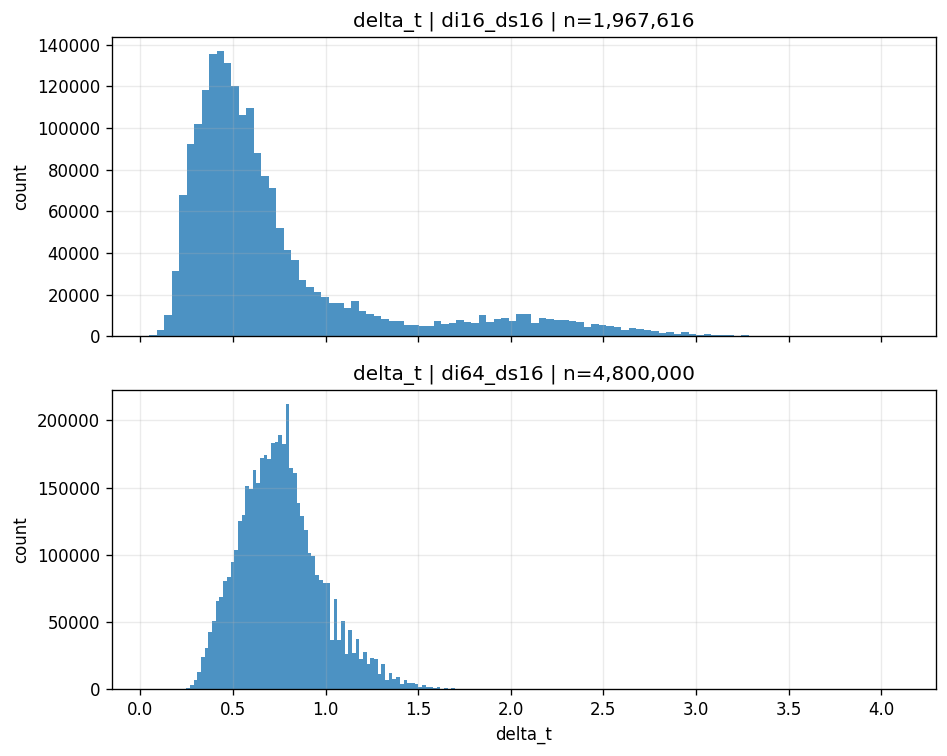

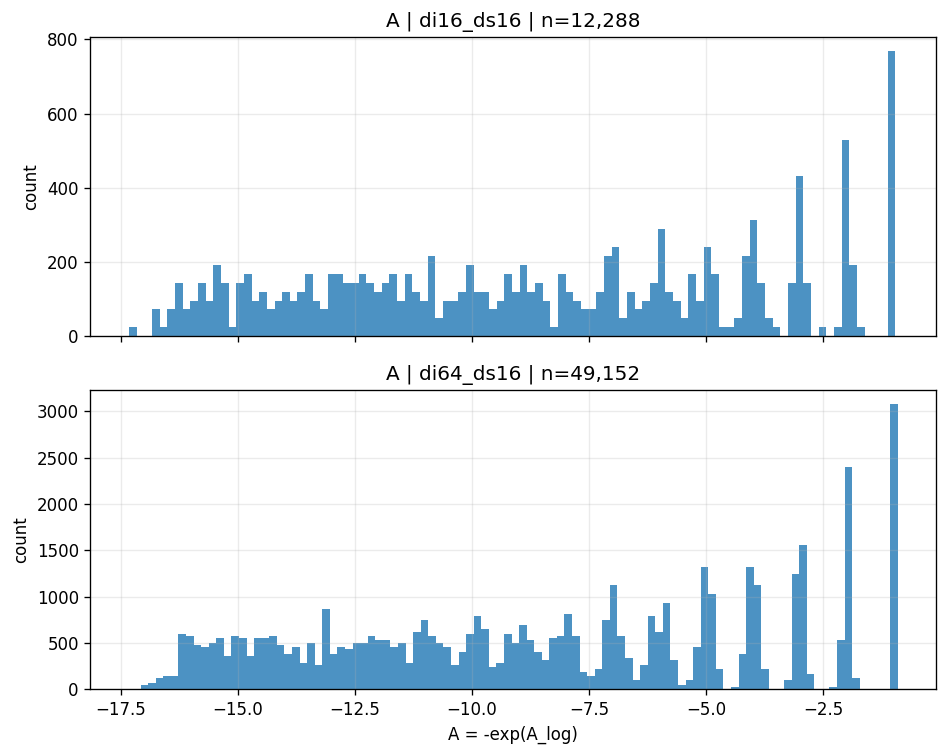

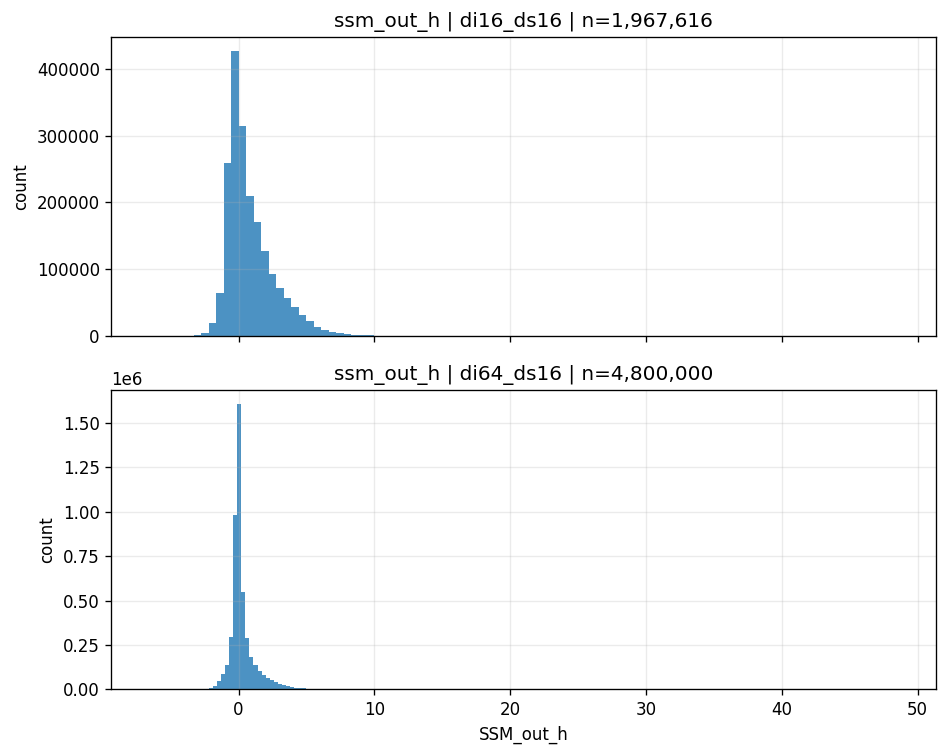

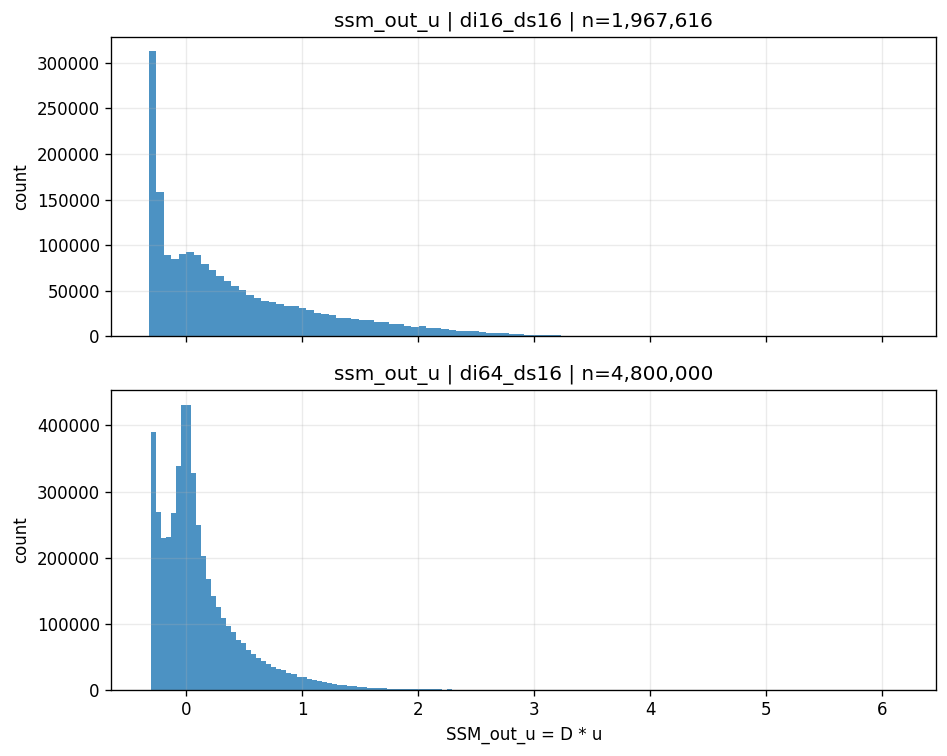

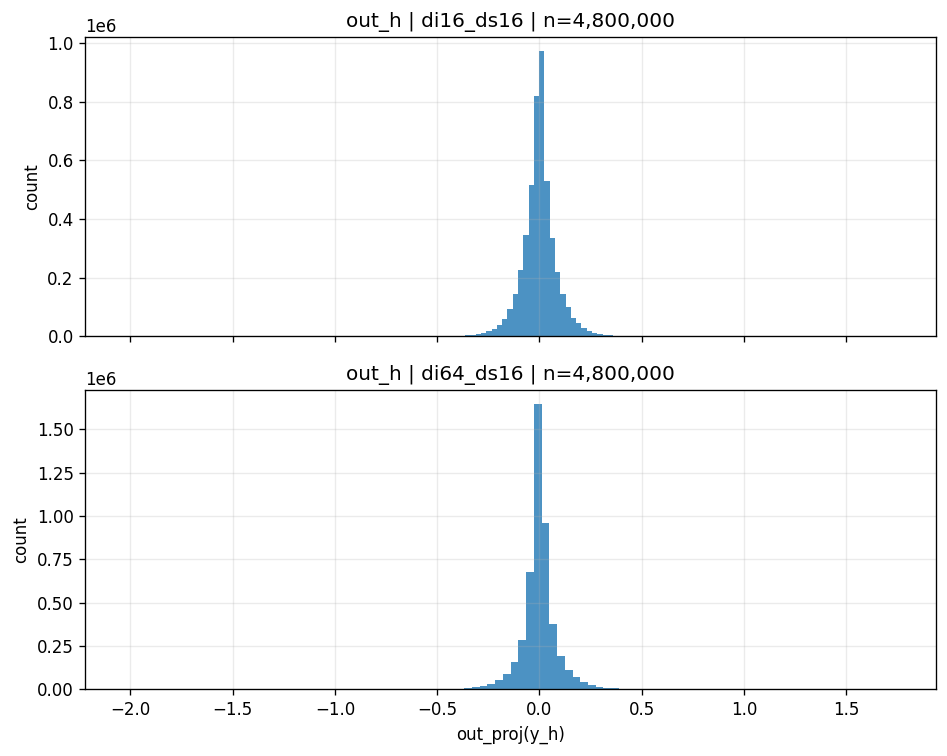

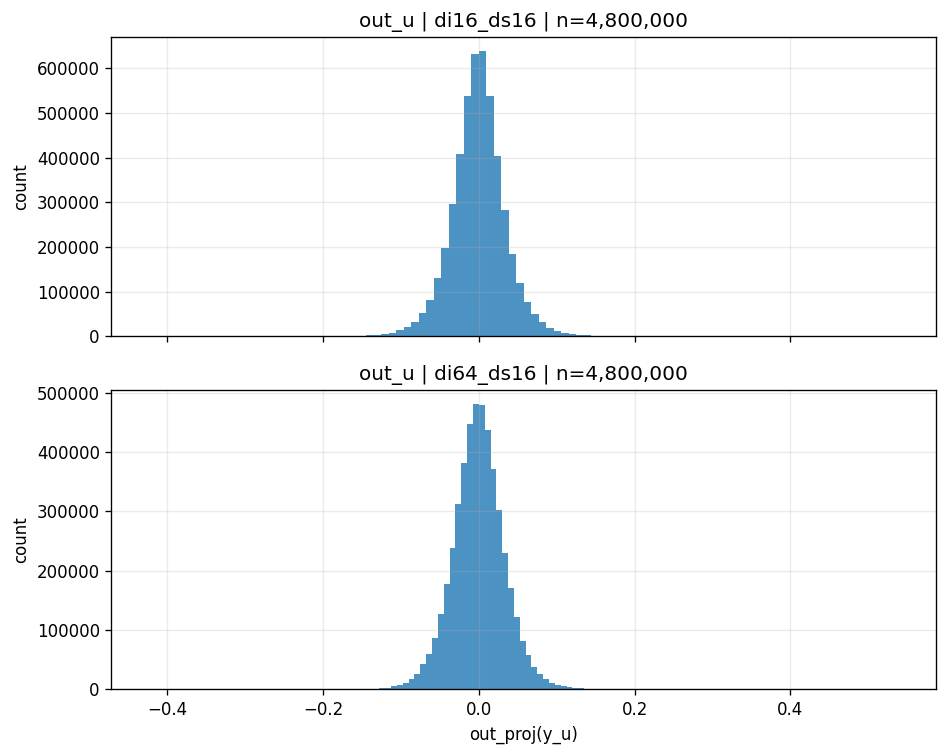

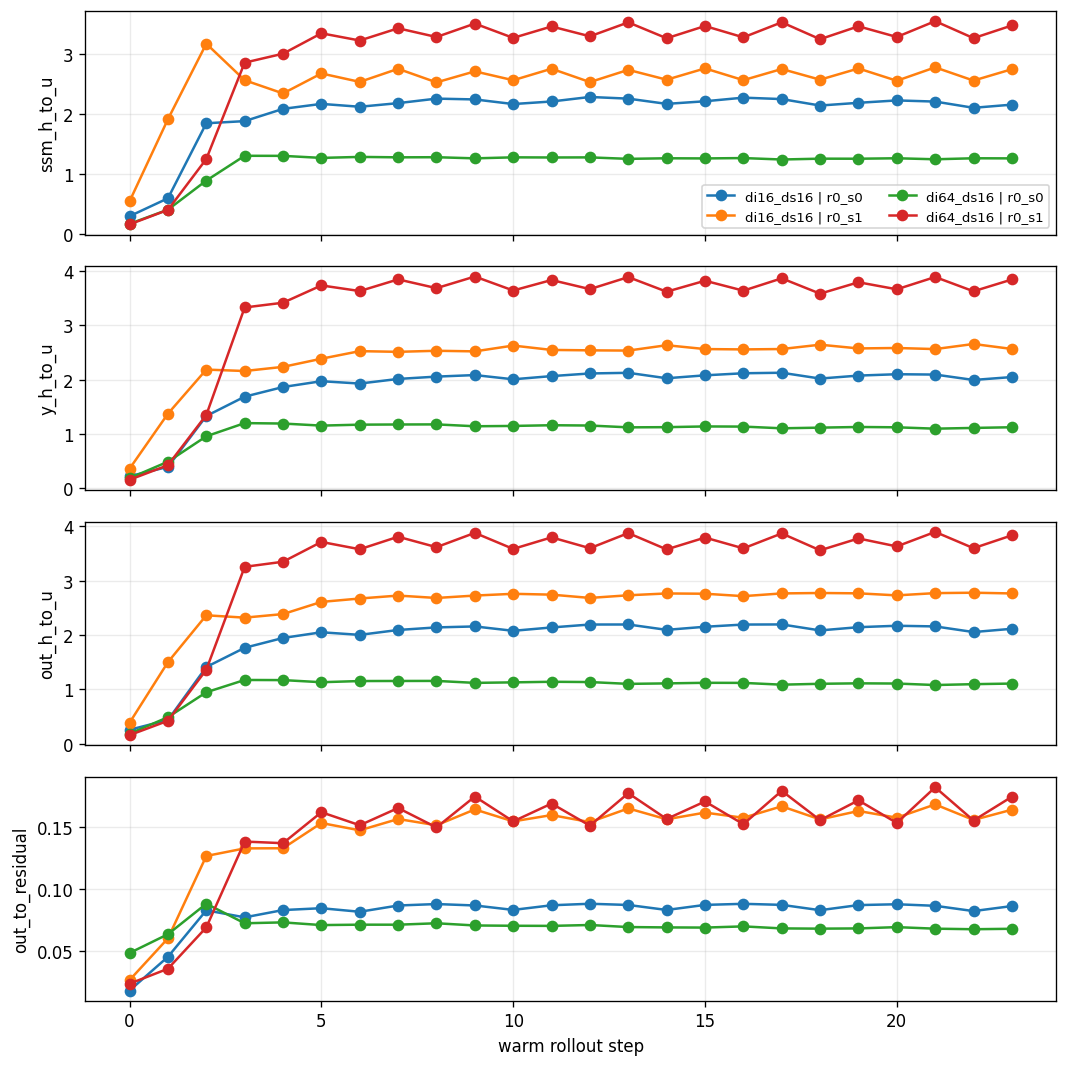

In [13]:
def flatten_for_plot(arr: np.ndarray, max_points: int = 200_000, seed: int = 0) -> np.ndarray:
    values = np.asarray(arr, dtype=np.float32).reshape(-1)
    values = values[np.isfinite(values)]
    if values.size > max_points:
        rng = np.random.default_rng(seed)
        values = values[rng.choice(values.size, size=max_points, replace=False)]
    return values


def values_by_run(quantity: str, *, max_points_per_leaf: int = 100_000) -> dict[str, np.ndarray]:
    out = {}
    for run, steps in TRACE_RESULTS.items():
        chunks = []
        for step_i, trace in enumerate(steps):
            for key, arr in trace.items():
                if key[2] == quantity:
                    chunks.append(flatten_for_plot(arr, max_points=max_points_per_leaf, seed=step_i))
        out[run] = np.concatenate(chunks) if chunks else np.array([], dtype=np.float32)
    return out


def plot_hist_by_run(quantity: str, *, bins: int = 80, xlim=None, transform=None, xlabel: str | None = None):
    by_run = values_by_run(quantity)
    fig, axes = plt.subplots(
        len(by_run), 1,
        figsize=(8, 3.2 * len(by_run)),
        sharex=True,
        sharey=False,
    )

    if len(by_run) == 1:
        axes = [axes]

    for ax, (run, values) in zip(axes, by_run.items()):
        if transform is not None:
            values = transform(values)

        ax.hist(values, bins=bins, alpha=0.8, density=False)
        ax.set_title(f"{quantity} | {run} | n={values.size:,}")
        ax.set_ylabel("count")
        ax.grid(True, alpha=0.25)

        if xlim is not None:
            ax.set_xlim(*xlim)

    axes[-1].set_xlabel(xlabel or quantity)
    fig.tight_layout()


def plot_ratio_timeseries(ratios: pd.DataFrame):
    metrics = ["ssm_h_to_u", "y_h_to_u", "out_h_to_u", "out_to_residual"]
    fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 9), sharex=True)
    for ax, metric in zip(axes, metrics):
        for (run, insertion), group in ratios.groupby(["run", "insertion"]):
            label = f"{run} | {insertion}"
            ax.plot(group["step"], group[metric], marker="o", label=label)
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel("warm rollout step")
    axes[0].legend(fontsize=8, ncol=2)
    fig.tight_layout()


plot_hist_by_run("delta_t", bins=100, xlabel="delta_t")
# plot_hist_by_run("effective_decay", bins=100, xlim=(-100, 0), transform=lambda x: np.log(np.clip(x, 1e-30, 1.0)), xlabel="delta_t * A")
plot_hist_by_run("A", bins=100, xlabel="A = -exp(A_log)")
plot_hist_by_run("ssm_out_h", bins=100, xlabel="SSM_out_h")
plot_hist_by_run("ssm_out_u", bins=100, xlabel="SSM_out_u = D * u")
plot_hist_by_run("out_h", bins=100, xlabel="out_proj(y_h)")
plot_hist_by_run("out_u", bins=100, xlabel="out_proj(y_u)")
plot_ratio_timeseries(RATIOS)


## Prediction Equivalence Smoke Check

This compares the first traced step with the untraced model for one checkpoint. It is intentionally separate because it compiles a second model. Run it when changing the traced block.


In [14]:
def max_prediction_diff(label: str = "di64_ds32") -> pd.DataFrame:
    traced_pred, _traces, _state = run_warm_trace(label, TRACE_BATCH, rollout_steps=1)
    untraced_pred, _ = run_one_untraced_step(label, TRACE_BATCH)
    untraced_pred = untraced_pred.assign_coords(time=traced_pred.coords["time"])
    rows = []
    for name in traced_pred.data_vars:
        diff = np.asarray(traced_pred[name] - untraced_pred[name], dtype=np.float32)
        rows.append({"variable": name, "max_abs_diff": float(np.nanmax(np.abs(diff)))})
    return pd.DataFrame(rows).sort_values("max_abs_diff", ascending=False)

# Uncomment after the main trace works if you want the full smoke check.
# PRED_DIFF = max_prediction_diff("di64_ds32")
# display(PRED_DIFF.head(20))
# assert PRED_DIFF["max_abs_diff"].max() < 5e-2
